In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.preprocessing import power_transform
from scipy.stats import norm

# **Function 1:** Searching for contamination sources

I am tasked with detecting likely contamination sources in a two-dimensional area, such as a radiation field, where only proximity yields a non-zero reading. The system uses Bayesian optimisation to tune detection parameters and reliably identify both strong and weak sources.

- **Optimisation Goal**: Maximise
- **Input:** 2D array. The initial dataset contained 12 observations. 
    - Now the data set includes my 12 weeks of manual and model-driven queries, the dataset now contains 22 data points.

- **All time best:** 2.80e-06 at [0.472, 0.352] (Week 5)

In [2]:
X = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_1/initial_inputs.npy')
Y = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_1/initial_outputs.npy')

# New data for Week 12 (Function 1)
X_w12_new_point = np.array([0.321608, 0.180905], dtype=np.float64)
Y_w12_new_point = np.array([4.694874888718636e-48], dtype=np.float64)

# Append the new data point
X_updated = np.vstack((X, X_w12_new_point.reshape(1, -1)))

# Remove duplicate X rows (if point already exists)
X_unique, unique_indices = np.unique(X_updated, axis=0, return_index=True)

# Build Y and keep matching rows only
Y_all = np.append(Y, Y_w12_new_point)
Y_updated = Y_all[unique_indices]

# Save the updated arrays
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_1/initial_inputs.npy', X_unique)
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_1/initial_outputs.npy', Y_updated)

print('Updated Inputs (X) - Function 1:', X_unique)
print('Updated Outputs (Y) - Function 1:', Y_updated)

Updated Inputs (X) - Function 1: [[0.08250725 0.40348751]
 [0.31269116 0.07872278]
 [0.31940389 0.76295937]
 [0.321608   0.180905  ]
 [0.378447   0.273576  ]
 [0.41043714 0.1475543 ]
 [0.472      0.332     ]
 [0.472361   0.351758  ]
 [0.521101   0.340595  ]
 [0.57432921 0.8798981 ]
 [0.575251   0.879599  ]
 [0.65011406 0.68152635]
 [0.68341817 0.86105746]
 [0.73102363 0.73299988]
 [0.732441   0.040134  ]
 [0.76642    0.752405  ]
 [0.799197   0.803213  ]
 [0.819277   0.694779  ]
 [0.84035342 0.26473161]
 [0.88388983 0.58225397]
 [0.919191   0.838383  ]
 [0.996651   0.001439  ]]
Updated Outputs (Y) - Function 1: [ 3.60677119e-081 -2.08909327e-091  1.32267704e-079  4.69487489e-048
 -4.58534168e-018 -2.15924904e-054  1.82102900e-008  2.80463460e-006
  2.38676658e-012  1.03307824e-046  1.46776061e-046 -3.60606264e-003
  2.53500115e-040  7.71087511e-016 -5.11184814e-169  4.64114908e-025
  4.75768881e-042 -1.84087865e-029  3.34177101e-124  6.22985647e-048
 -3.04056455e-090  0.00000000e+000]


## **Output Analysis**

- **W11 Output:** $2.39 \times 10^{-12}$ at [0.521, 0.341]
- **W12 Output:** $4.69 \times 10^{-48}$ at [0.321, 0.181] — effectively zero

- **Comparison:** W12 queried [0.321, 0.181], which is far from the confirmed x1≈0.472 corridor. 
    - The result is machine-zero.
        - This confirms once again that only the narrow band around x1=0.472 produces any signal.

    - Three positive readings in twelve weeks all share x1≈0.472; every query elsewhere returns zero.

- **Real-World Implication:** In radiation detection, repeated zero readings outside a specific zone are not failures as they are boundary evidence. 
    - We now have strong empirical evidence that the contamination source is localised in a very narrow x1 corridor. 
    - Every off-corridor query wastes a week.

- **Model Clues:** W13 must commit to querying directly at x1=0.472 with a small step in x2. The W5 best [0.472, 0.352] remains the all-time best. 

- w13 will query one step above it at [0.472, 0.370] to test whether the signal continues to increase northward.

## **Bayesian Optimisation** - Gaissian Process Regressor

- The Gaussian Process with a Matern (ν=2.5) kernel and WhiteKernel noise component is retained without changes. 
    - With only three meaningful non-zero positive readings across twelve weeks, the GP's role here is not to predict the function's shape, it has insufficient data for that, but to map which regions carry the highest uncertainty so that future queries are directed meaningfully. 
    
- The Matern 2.5 kernel was chosen from the outset because it assumes twice-differentiable functions, which is appropriate for a physical radiation field where signal intensity decays smoothly with distance from the source. 
    - The WhiteKernel component absorbs the near-zero noise floor that dominates most of the dataset. 
    
- The Yeo-Johnson transformation remains essential: the output range spans from machine-zero to 2.80×10⁻⁶, and without this transformation the GP would treat all near-zero readings as identical, destroying any gradient information the model could otherwise learn. 

- Increasing n_restarts_optimizer to 15 ensures the marginal likelihood is optimised from multiple starting points, reducing the risk of the kernel converging to a degenerate fit given the sparse signal data.

In [3]:
Y_transformed = power_transform(Y_updated.reshape(-1, 1), method='yeo-johnson').ravel()

print('Original Y:', Y_updated)
print('Transformed Y:', Y_transformed)

kernel = Matern(nu=2.5) + WhiteKernel(noise_level=1e-5)

model = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=20)

model.fit(X_unique, Y_transformed)

Original Y: [ 3.60677119e-081 -2.08909327e-091  1.32267704e-079  4.69487489e-048
 -4.58534168e-018 -2.15924904e-054  1.82102900e-008  2.80463460e-006
  2.38676658e-012  1.03307824e-046  1.46776061e-046 -3.60606264e-003
  2.53500115e-040  7.71087511e-016 -5.11184814e-169  4.64114908e-025
  4.75768881e-042 -1.84087865e-029  3.34177101e-124  6.22985647e-048
 -3.04056455e-090  0.00000000e+000]
Transformed Y: [ 0.21506373  0.21506373  0.21506373  0.21506373  0.21506373  0.21506373
  0.21548546  0.28045549  0.21506378  0.21506373  0.21506373 -4.58215179
  0.21506373  0.21506373  0.21506373  0.21506373  0.21506373  0.21506373
  0.21506373  0.21506373  0.21506373  0.21506373]


/Users/prathamyeole/Library/Python/3.13/lib/python/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".",Matern(length...e_level=1e-05)
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",1e-10
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",20
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",False
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`

## **Next Query Selection** - Pure Exploration based on w5 best

- The acquisition function is bypassed entirely this week in favour of a deterministic northward step to [0.472, 0.370]. 
    - This is a deliberate methodological choice, not a limitation. 
    - When the dataset contains only three non-zero readings and the current maximum is so small that EI becomes numerically unstable, improvement over 2.80×10⁻⁶ is smaller than floating-point precision in many configurations.
        - Therefore, both EI and UCB fail to provide meaningful guidance. 

- UCB would simply select the most uncertain region of the space, which twelve weeks of experience have shown produces nothing. 

- EI would produce a near-zero acquisition surface with no meaningful peak. 

- The most information-efficient query (pure-exploration) at this stage is a controlled directional step: the two positive readings at [0.472, 0.352] and [0.472, 0.332] confirmed a northward gradient, so stepping to [0.472, 0.370] 
    - One increment above the all-time best either finds a stronger signal (confirming the source is north of 0.352) or a weaker signal (confirming 0.352 is near the peak). 
    - Both outcomes are maximally informative for the GP's next fit.

In [4]:
# Deterministic northward step — no acquisition function
# Rationale: Deterministic northward step above W5 best. UCB/EI both fail near-zero landscapes.
next_query = np.clip(np.array([0.472361, 0.37]), 0.000001, 0.999999)

print(f'Week 13 Query Recommendation (Function 1): {next_query[0]:.6f}-{next_query[1]:.6f}')

Week 13 Query Recommendation (Function 1): 0.472361-0.370000


## **Visualisation**

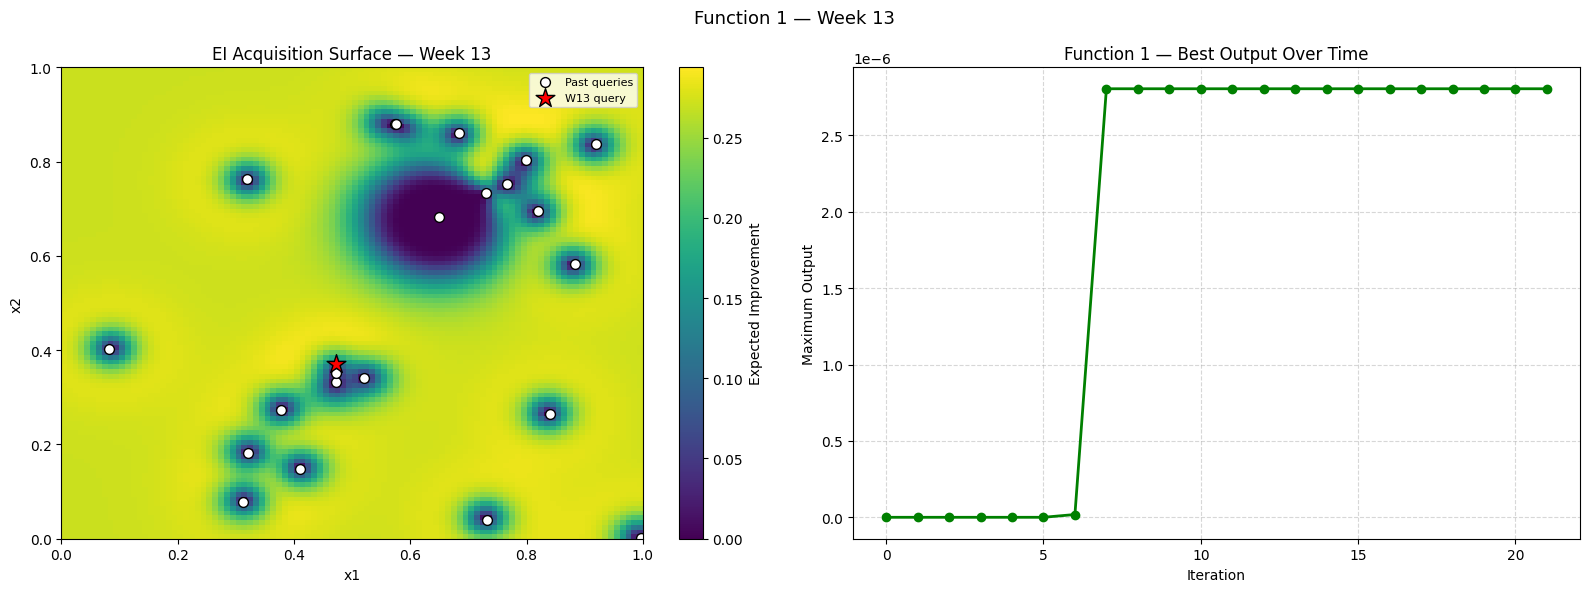

In [5]:
res = 100
X1, X2 = np.meshgrid(np.linspace(0, 1, res), np.linspace(0, 1, res))
X_plot = np.vstack([X1.ravel(), X2.ravel()]).T

y_max_vis = np.max(Y_transformed)

def expected_improvement_vis(X, model, y_max, xi=0.01):
    mu, sigma = model.predict(X, return_std=True)
    sigma = sigma.reshape(-1, 1); mu = mu.reshape(-1, 1)
    with np.errstate(divide='warn'):
        improvement = mu - y_max - xi
        Z = improvement / sigma
        ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

ei_plot = expected_improvement_vis(X_plot, model, y_max_vis).reshape(res, res)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sc = ax1.imshow(ei_plot, extent=[0,1,0,1], origin='lower', cmap='viridis', aspect='auto')
plt.colorbar(sc, ax=ax1, label='Expected Improvement')
ax1.scatter(X_unique[:,0], X_unique[:,1], c='white', edgecolors='black', s=50, label='Past queries')
ax1.scatter(next_query[0], next_query[1], c='red', marker='*', s=200, edgecolors='black', zorder=7, label='W13 query')
ax1.set_title('EI Acquisition Surface — Week 13')
ax1.set_xlabel('x1'); ax1.set_ylabel('x2'); ax1.legend(fontsize=8)

running_max = np.maximum.accumulate(Y_updated)
ax2.plot(running_max, marker='o', color='green', linewidth=2)
ax2.set_title('Function 1 — Best Output Over Time')
ax2.set_xlabel('Iteration'); ax2.set_ylabel('Maximum Output')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Function 1 — Week 13', fontsize=13)
plt.tight_layout()
plt.show()